# Project 5: Classifying Point Clouds with PointNet

For this project, we are going to build deep learning architectures to classify point clouds that were extracted from self-driving car LiDAR scans.

Basic learning objectives of this project:
* Construct the basic pipeline used for point cloud classification
* Analyze the results from our model and look for potential points of improvement
* Understand the limitations of the model and improve it using positional encodings

## Setup

In [1]:
import sys
sys.path.insert(0, 'src')

In [2]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import torch
from vision.utils import verify

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [3]:
device = torch.device('cpu')
# If you have an NVIDIA GPU with at least 2 GB of VRAM, set this to True
use_cuda = False
# If you have an Apple Silicon Mac, set this to True
use_apple_silicon = False
if torch.cuda.is_available():
    if use_cuda:
        device = torch.device('cuda')
        print("CUDA-compatible NVIDIA GPU enabled.")
    else:
        print("CUDA-compatible NVIDIA GPU detected. Consider setting use_cuda to True.")
if torch.backends.mps.is_available() and torch.backends.mps.is_built():
    if use_apple_silicon:
        device = torch.device('mps')
        print("Apple Silicon GPU enabled.")
    else:
        print("Apple Silicon GPU detected. Consider setting use_apple_silicon to True.")
        

print("Using device: %s" % str(device))

Apple Silicon GPU detected. Consider setting use_apple_silicon to True.
Using device: cpu


Lets take a second to visualize a few point clouds that we are going to train our model on. You might need to rotate the visualization before you can actually see the object being represented by the points. See if you can make out this pedestrian's arms, legs, and head.

In [4]:
from vision.utils import plot_cloud_from_file

plot_cloud_from_file('data/sweeps/PEDESTRIAN/11.txt')

## Part 1: Data Loading

The first order of business we're going to take care of is writing a PyTorch dataset that will load in the data we'll be using to train and test our model. We have a total of 20 different classes that all found under the `data/sweeps` folder and each class has been split into a training and testing set. We will write a class that will load the appropriate data given the split we pass in (i.e. train/test split).

**TODO 1:** complete `part1_dataloader.py`

In [5]:
from vision.part1_dataloader import Argoverse
from torch.utils.data import DataLoader
from tests.test_part1 import (
    test_dataset_length, 
    test_unique_values, 
    test_get_points_from_file, 
    test_pad_points, 
    test_class_values
)

In [6]:
print("test_dataset_length(): ", verify(test_dataset_length))
print("test_unique_values(): ", verify(test_unique_values))
print("test_get_points_from_file(): ", verify(test_get_points_from_file))
print("test_pad_points(): ", verify(test_pad_points))
print("test_class_values(): ", verify(test_class_values))

test_dataset_length():  "Correct"
test_unique_values():  "Correct"
test_get_points_from_file():  "Correct"
test_pad_points():  "Correct"
test_class_values():  "Correct"


Now we can load in our data. When extracting object point clouds from LiDAR scans, we pruned point clouds with large numbers of points to reduce the computational demand of training and testing our classifiers. We pruned all point clouds to have a maximum of 200 points so that is the size that we will be padding all of the other point clouds to. (Feel free to adjust the batch size if you find a value that works better with your implementation)

In [7]:
train_dataset = Argoverse('train', 'data/sweeps', 200)
test_dataset = Argoverse('test', 'data/sweeps', 200)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=True)

## Part 2: Baseline

A very simple baseline to start with is a voxel-based approach. Our overall point cloud falls in a 4x4x4 meter volume in space. We can divide this up into 1x1x1 meter volumes which would give us a total of 64 $1m^3$ cells. We build a 64-dimensional feature for a point by simply counting how many points in the point cloud fall into each cell then normalizng the resulting feature vector.

For more details see the project pdf.

**TODO 2:** complete `part2_baseline.py`

In [8]:
from vision.part2_baseline import Baseline
from torch import optim
from vision.training import train, test
from tests.test_part2 import (
    test_count_points,
    test_baseline
)

In [9]:
print("test_count_points(): ", verify(test_count_points))
print("test_baseline(): ", verify(test_baseline))

test_count_points():  "Correct"
test_baseline():  "Correct"


Lets train our baseline implementation and see how it does! Fill in the hyperparameters and train your model. 

To get full credit for this section, you will need *$\geq$ 30%* accuracy on the test data set. The TAs were able to consistently achieve this accuracy with ~15 epochs.

*Hint: Play around with different voxel resolutions and the two different modes you implemented to see which configuration works the best.*

In [10]:
lr = 0.05
weight_decay = 1e-4
epochs = 15

model = Baseline(20, voxel_resolution=8, mode="occupancy")
optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

In [11]:
train_acc, train_loss, test_acc, test_loss = train(model, optimizer, epochs, train_loader, test_loader)

Epoch 1

Training...


100%|██████████| 213/213 [00:01<00:00, 107.69it/s]



Testing...


100%|██████████| 38/38 [00:00<00:00, 146.85it/s]
/Users/architam/Documents/spring 26/intro to cv/project-5-student/src/vision/training.py:94: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runnerx/miniforge3/conda-bld/libtorch_1769685250281/work/torch/csrc/autograd/generated/python_variable_methods.cpp:837.)
  print('\tTraining loss: %0.4f' % train_avg_loss)



Epoch 1 Stats:
	Training accuracy: 0.5585
	Training loss: 1.4670
	Validation accuracy: 0.4567
	Validation loss: 2.2304

Validation accuracy improved from 0 to 0.4566666781902313
Saving model to Baseline.pt


Epoch 2

Training...


...


Epoch 14 Stats:
	Training accuracy: 0.6979
	Training loss: 0.9056
	Validation accuracy: 0.4700
	Validation loss: 2.6905


Epoch 15

Training...


100%|██████████| 213/213 [00:01<00:00, 198.49it/s]



Testing...


100%|██████████| 38/38 [00:00<00:00, 164.70it/s]


Epoch 15 Stats:
	Training accuracy: 0.7094
	Training loss: 0.8517
	Validation accuracy: 0.4617
	Validation loss: 2.9586




In [12]:
model = torch.load('output/Baseline.pt', weights_only=False)
test_acc, test_loss = test(model, test_loader)

100%|██████████| 38/38 [00:00<00:00, 216.21it/s]

Test accuracy: 0.5000
Test loss: 3.1319


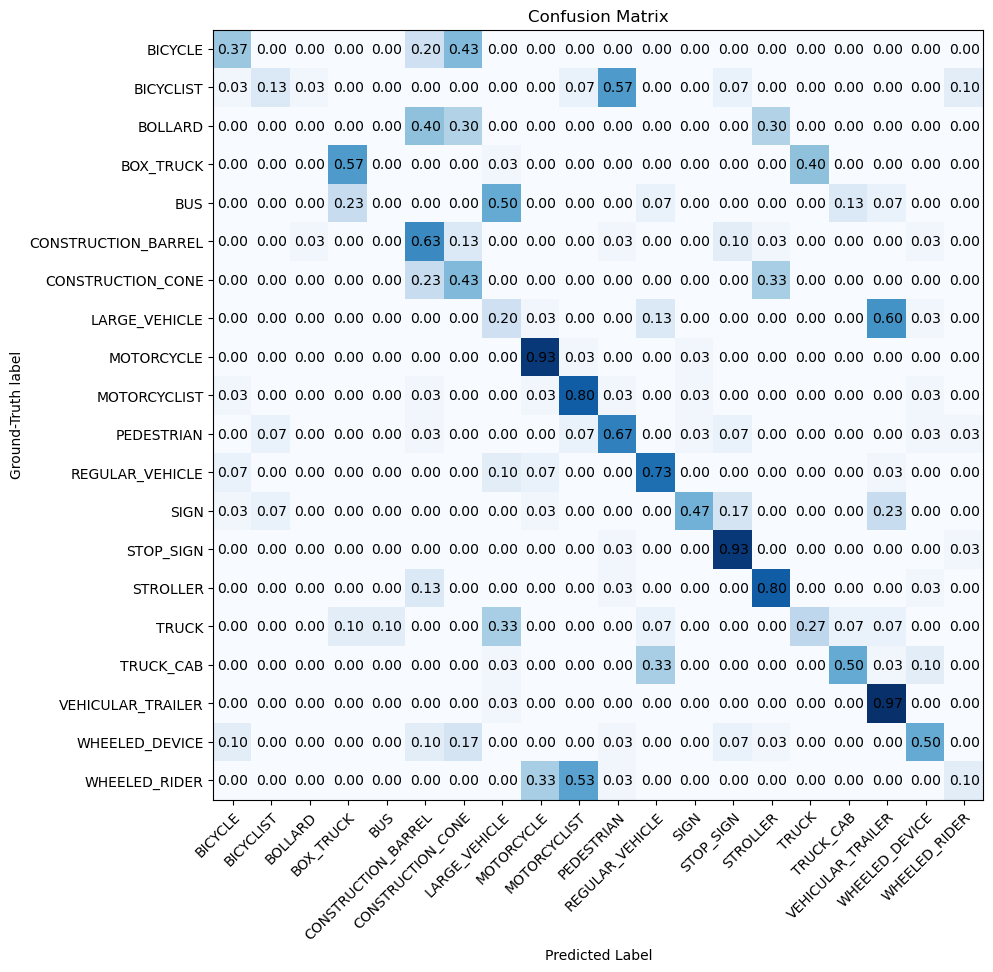

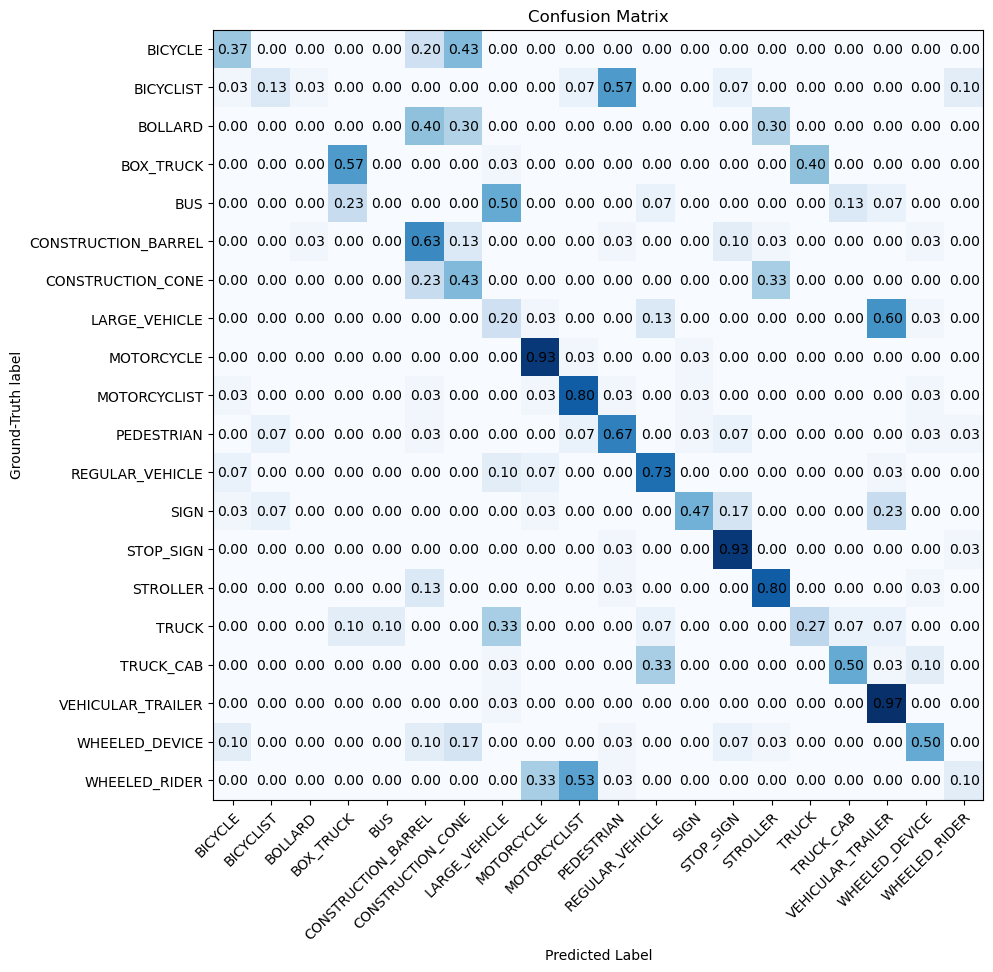

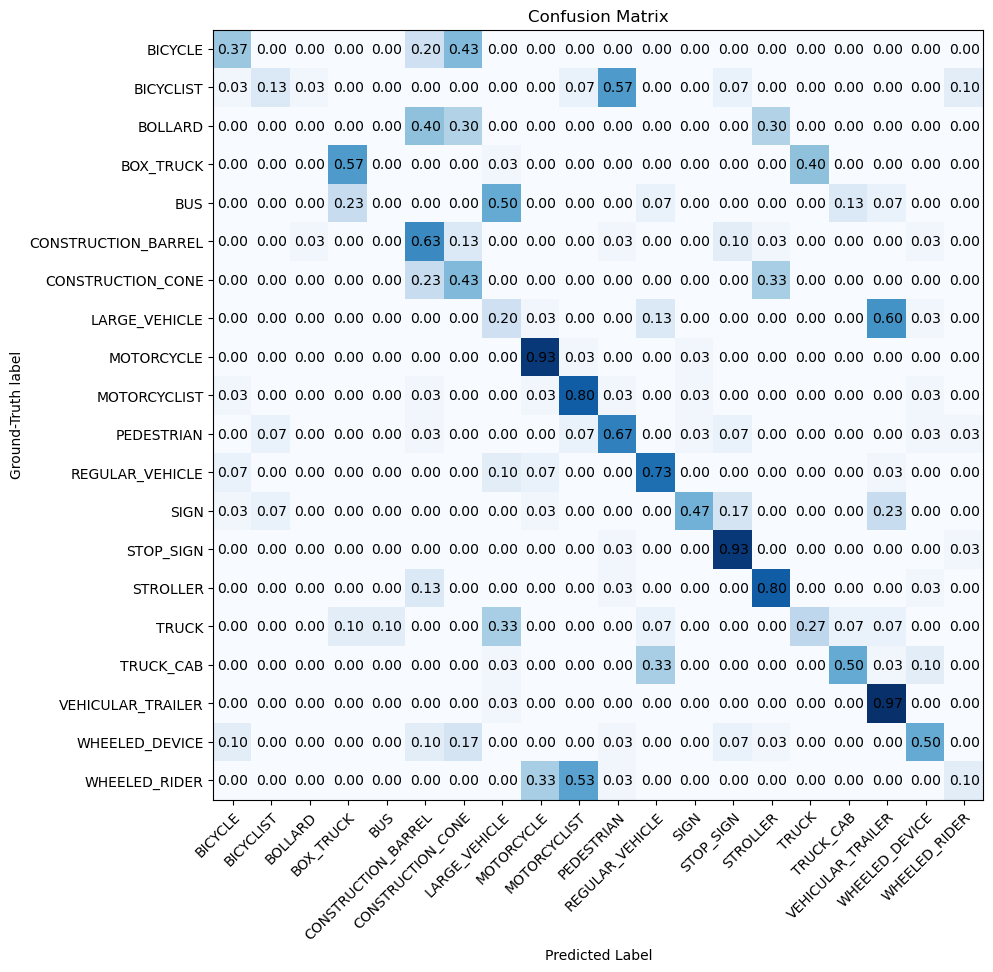

Saved!


<Figure size 640x480 with 0 Axes>

In [38]:
%matplotlib inline
import matplotlib.pyplot as plt
from vision.utils import generate_and_plot_confusion_matrix, plot_confusion_matrix
from vision.part4_analysis import get_confusion_matrix

model_baseline = torch.load('output/Baseline.pt', weights_only=False)

# Display inline in notebook
generate_and_plot_confusion_matrix(model_baseline, test_loader, 20)
plt.savefig('output/confusion_baseline.png', bbox_inches='tight', dpi=150)
print("Saved!")

## Part 3: PointNet

Now that we have a baseline to compare to, we're going to build a simplified version of PointNet which was first published in 2017 by researchers at Stanford University. You can view the original website for this publication [here](https://stanford.edu/~rqi/pointnet/). 

We will be slightly modifying the original architecture. The architecture described in the PointNet publication includes two modules that we will not be implementing. Namely, they are the input transform and the feature transform. We will also not be using our PointNet implementation for semantic segmentation so you can ignore that part of the architecture as well. For an architecture diagram of what we will be implementing, check the project pdf.

**TODO 3**: complete `part3_pointnet.py`, use the architecture diagram in the project pdf for reference.

In [13]:
from tests.test_part3 import test_pointnet
from vision.part3_pointnet import PointNet

In [14]:
print("test_pointnet(): ", verify(test_pointnet))

test_pointnet():  "Correct"


Now that we have a PointNet implementation, lets train our model and see how it does. Fill in the hyper-parameters and give your new model a spin! 

To get full credit for this section, you will need *$\geq$ 60% accuracy* on the test dataset. The TAs were able to consistently achieve this accuracy with ~15 epochs of training.

In [ ]:
lr = 0.001
weight_decay = 1e-4
epochs = 15

model = PointNet(classes=20)
optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

In [16]:
train_acc, train_loss, test_acc, test_loss = train(model, optimizer, epochs, train_loader, test_loader, device=device)

Epoch 1

Training...


100%|██████████| 213/213 [00:09<00:00, 22.40it/s]



Testing...


100%|██████████| 38/38 [00:00<00:00, 57.74it/s]



Epoch 1 Stats:
	Training accuracy: 0.3162
	Training loss: 1.9439
	Validation accuracy: 0.4700
	Validation loss: 1.6449

Validation accuracy improved from 0 to 0.4699999988079071
Saving model to PointNet.pt


Epoch 2

Training...


...


Epoch 14 Stats:
	Training accuracy: 0.8415
	Training loss: 0.4683
	Validation accuracy: 0.5617
	Validation loss: 1.4484


Epoch 15

Training...


100%|██████████| 213/213 [00:10<00:00, 20.37it/s]



Testing...


100%|██████████| 38/38 [00:00<00:00, 51.23it/s]



Epoch 15 Stats:
	Training accuracy: 0.8418
	Training loss: 0.4657
	Validation accuracy: 0.6317
	Validation loss: 1.2504

Validation accuracy improved from 0.6233333349227905 to 0.6316666603088379
Saving model to PointNet.pt




In [17]:
model = torch.load('output/PointNet.pt', weights_only=False)
test_acc, test_loss = test(model, test_loader)

100%|██████████| 38/38 [00:00<00:00, 56.06it/s]

Test accuracy: 0.6317
Test loss: 1.2649


## Part 4: Performance Analysis

Now that we have a trained PointNet model, we can look at how it performs and what its shortcomings are. We are also going to analyze our point clouds to see which parts of them the model deemed to be most important in making its classification decision.

**TODO 4:** complete `part4_analysis.py`

In [18]:
from vision.utils import (
    generate_and_plot_confusion_matrix,
    plot_crit_points_from_file
)
from tests.test_part4 import (
    test_critical_indices,
    test_critical_indices_with_duplicates,
    test_confusion_matrix,
    test_confusion_matrix_normalized
)

In [19]:
print("test_critical_indices(): ", verify(test_critical_indices))
print("test_critical_indices_with_duplicates(): ", verify(test_critical_indices_with_duplicates))
print("test_confusion_matrix(): ", verify(test_confusion_matrix))
print("test_confusion_matrix_normalized(): ", verify(test_confusion_matrix_normalized))

test_critical_indices():  "Correct"
test_critical_indices_with_duplicates():  "Correct"
test_confusion_matrix():  "Correct"
test_confusion_matrix_normalized():  "Correct"


Lets use the confusion matrix to look at which mistakes our model is making most often.

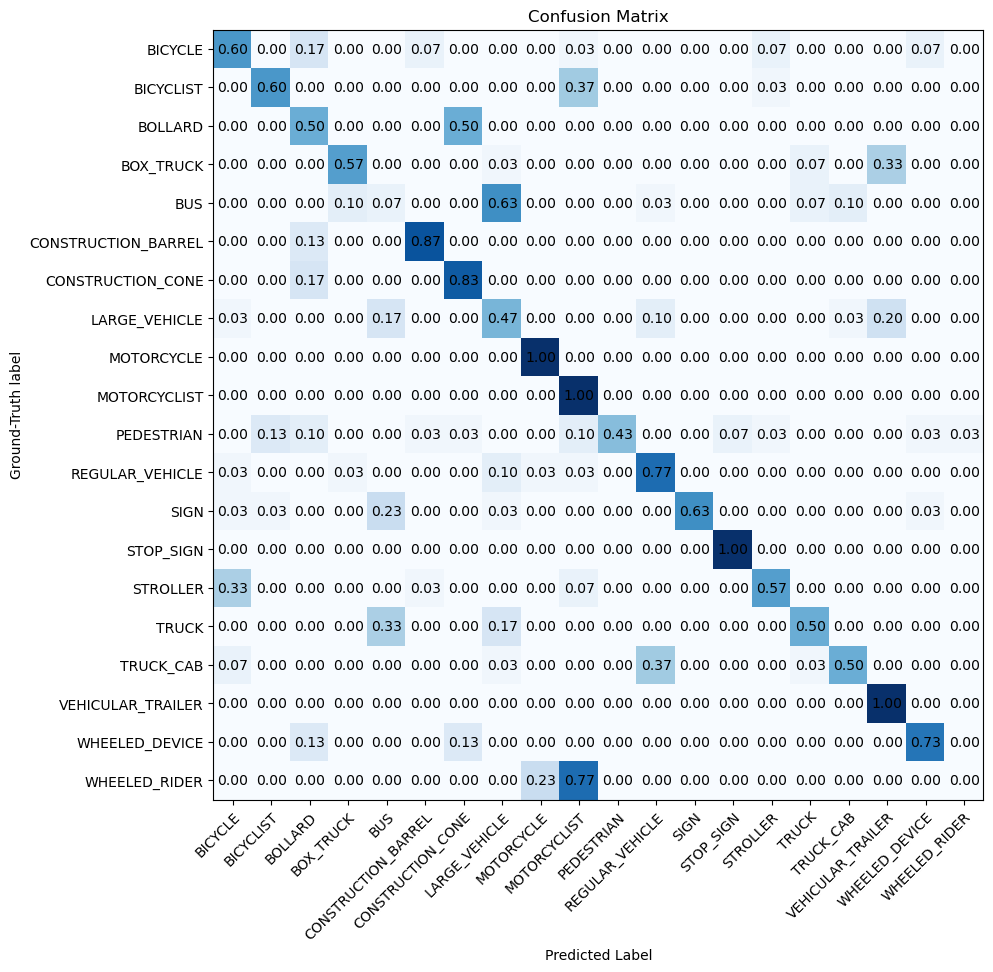

In [20]:
generate_and_plot_confusion_matrix(model, test_loader, 20)

Now lets visualize the critical points calculated by our model for the predestrian clouds from before. Recall that these are the points that contributed to the global feature. Why do you think these were the critical points the model ended up using? (Feel free to use different point clouds for your analysis)

In [21]:
plot_crit_points_from_file(model, 'data/sweeps/PEDESTRIAN/11.txt', 200)

## Part 5: T-Net (Extra Credit)

Our basic PointNet model does pretty well. But let's see if we can do any better. One proposed solution to improve on the shortcomings of the basic PointNet model is using a T-Net (see pdf for more details). 

**TODO 5:** complete `part5_tnet.py`

In [22]:
from vision.part5_tnet import PointNetTNet
from tests.test_part5 import (
    test_tnet_shapes,
    test_pointnet_tnet
)

In [23]:
print("test_tnet_shapes(): ", verify(test_tnet_shapes))
print("test_pointnet_tnet(): ", verify(test_pointnet_tnet))

test_tnet_shapes():  "Correct"
test_pointnet_tnet():  "Correct"


Let's check out how our model performs now that we added a T-Net.

To get full credit for this section, you will need *$\geq$ 65% accuracy* on the test dataset. The TAs were able to achieve this accuracy with ~15 epochs of training. 

*Hint 1: You may need to play around with the number of layers in the T-Net*

*Hint 2: T-Net is sensitive to the initialization so you should try training the same model more than once*

In [31]:
lr = 0.002
weight_decay = 1e-4
epochs = 20

model = PointNetTNet(classes=20)
optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

In [34]:
import shutil

best_acc = 0.625  # start from your current best so we don't overwrite it
shutil.copy('output/PointNetTNet.pt', 'output/PointNetTNet_best.pt')

for attempt in range(10):
    print(f"\n=== Attempt {attempt+1} ===")
    model_tnet = PointNetTNet(classes=20, pts_per_obj=200)
    optimizer = torch.optim.Adam(model_tnet.parameters(), lr=0.002, weight_decay=1e-4)
    
    train_acc, train_loss, val_acc, val_loss = train(
        model_tnet, optimizer, 20, train_loader, test_loader
    )
    
    saved = torch.load('output/PointNetTNet.pt', weights_only=False)
    acc, loss = test(saved, test_loader)
    print(f"Attempt {attempt+1} accuracy: {acc:.4f}")
    
    if acc > best_acc:
        best_acc = acc
        shutil.copy('output/PointNetTNet.pt', 'output/PointNetTNet_best.pt')
        print(f"New best: {best_acc:.4f} — backed up!")
    
    if best_acc >= 0.65:
        print("Hit 65%! Stopping.")
        break

# Restore best
shutil.copy('output/PointNetTNet_best.pt', 'output/PointNetTNet.pt')
print(f"\nFinal best: {best_acc:.4f}")

# Verify
model = torch.load('output/PointNetTNet.pt', weights_only=False)
test(model, test_loader)


=== Attempt 1 ===
Epoch 1

Training...


100%|██████████| 213/213 [00:20<00:00, 10.50it/s]



Testing...


100%|██████████| 38/38 [00:01<00:00, 29.51it/s]



Epoch 1 Stats:
	Training accuracy: 0.1965
	Training loss: 2.2876
	Validation accuracy: 0.2617
	Validation loss: 2.0085

Validation accuracy improved from 0 to 0.2616666555404663
Saving model to PointNetTNet.pt


Epoch 2

Training...


...

100%|██████████| 38/38 [00:01<00:00, 27.54it/s]


Test accuracy: 0.6583
Test loss: 1.2599
Attempt 2 accuracy: 0.6583
New best: 0.6583 — backed up!
Hit 65%! Stopping.

Final best: 0.6583


100%|██████████| 38/38 [00:01<00:00, 28.23it/s]


Test accuracy: 0.6583
Test loss: 1.2798


(tensor(0.6583), tensor(1.2798))

In [32]:
train_acc, train_loss, test_acc, test_loss = train(model, optimizer, epochs, train_loader, test_loader, device=device)

Epoch 1

Training...


100%|██████████| 213/213 [00:20<00:00, 10.58it/s]



Testing...


100%|██████████| 38/38 [00:01<00:00, 26.62it/s]



Epoch 1 Stats:
	Training accuracy: 0.2141
	Training loss: 2.2832
	Validation accuracy: 0.2767
	Validation loss: 2.1520

Validation accuracy improved from 0 to 0.27666667103767395
Saving model to PointNetTNet.pt


Epoch 2

Training...


...


Epoch 19 Stats:
	Training accuracy: 0.8282
	Training loss: 0.5206
	Validation accuracy: 0.6233
	Validation loss: 1.2892


Epoch 20

Training...


100%|██████████| 213/213 [00:20<00:00, 10.64it/s]



Testing...


100%|██████████| 38/38 [00:01<00:00, 27.15it/s]



Epoch 20 Stats:
	Training accuracy: 0.8474
	Training loss: 0.4636
	Validation accuracy: 0.6233
	Validation loss: 1.4748




In [26]:
model = torch.load('output/PointNetTNet.pt', weights_only=False)
test_acc, test_loss = test(model, test_loader)

100%|██████████| 38/38 [00:01<00:00, 27.14it/s]

Test accuracy: 0.6250
Test loss: 1.2405


Lets take a look at how the addition of positional encoding improved on the performance of our original PointNet model. Which classes does the positional encoding help the most with? Which ones does it not really seem to make much of a difference for? Why?

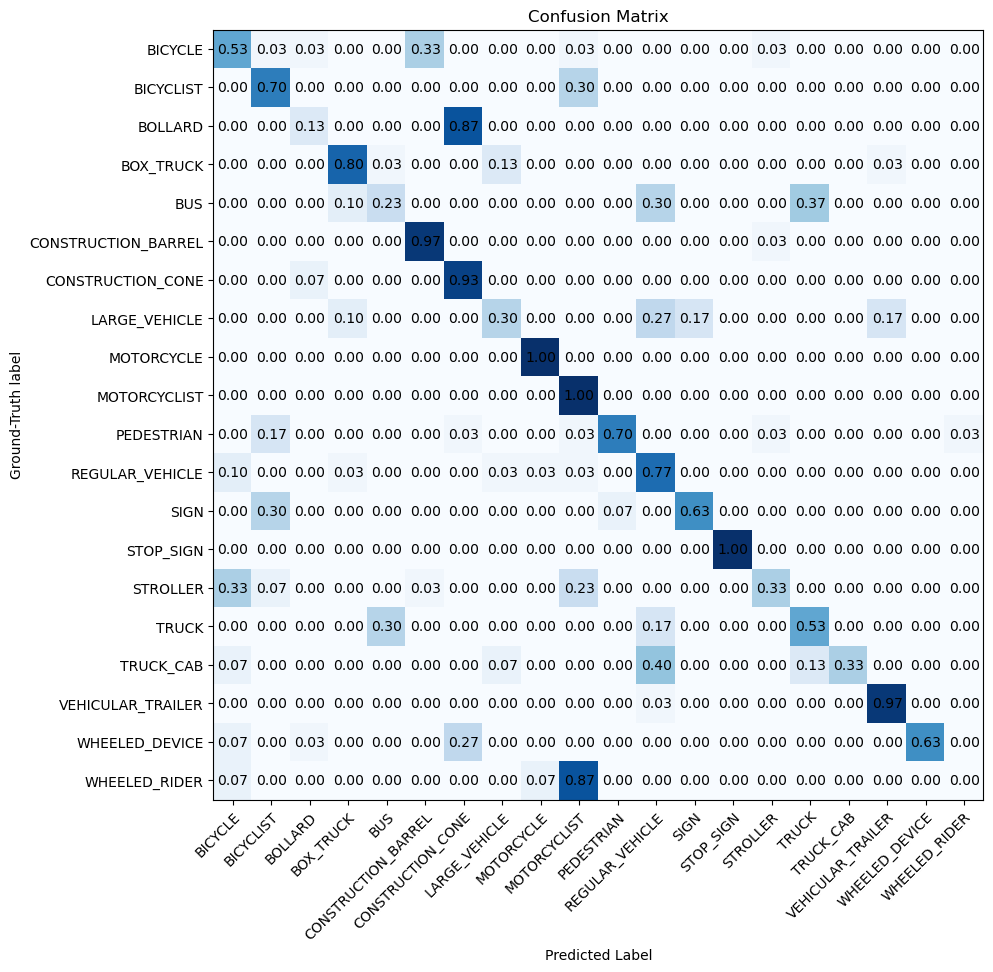

In [27]:
generate_and_plot_confusion_matrix(model, test_loader, 20)

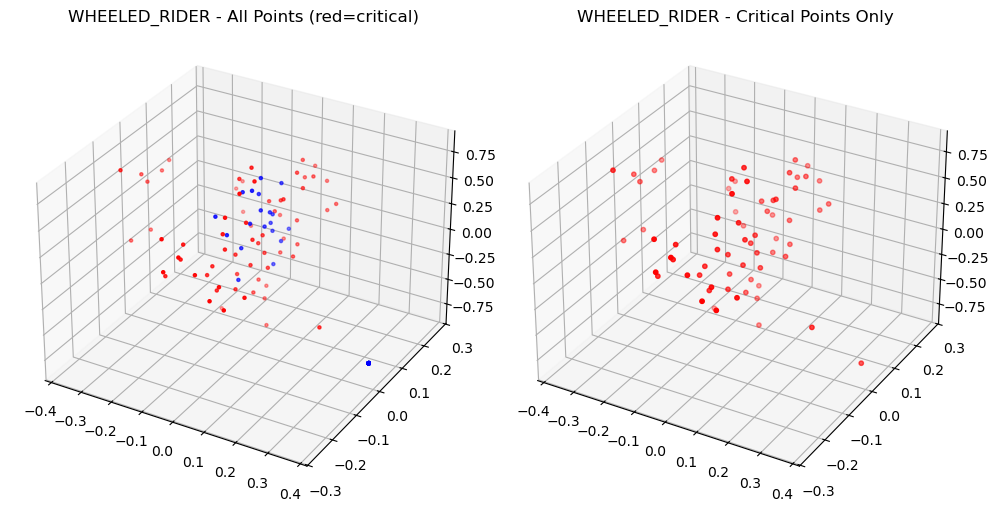

WHEELED_RIDER: 69 critical points


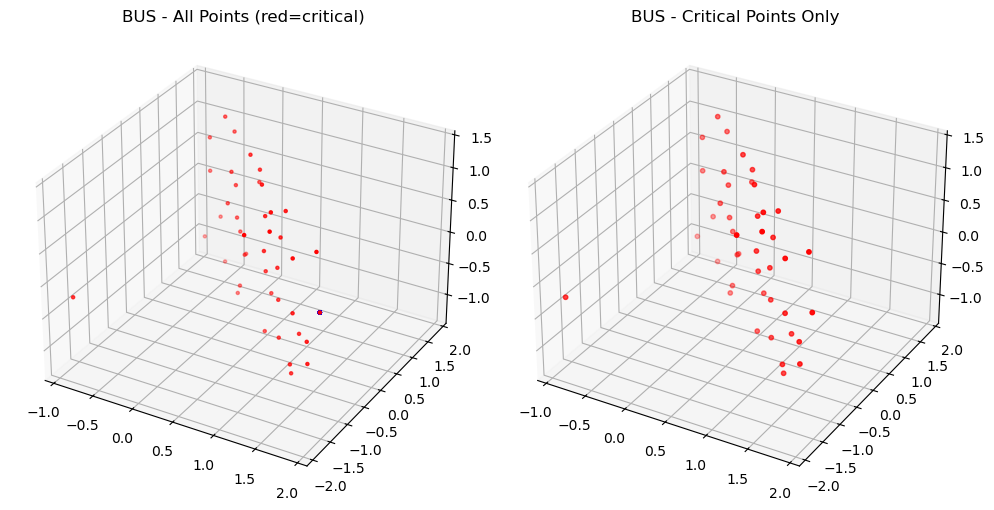

BUS: 43 critical points


In [43]:
%matplotlib inline

def plot_critical_for_class(class_name, file_idx=11):
    pts_np = read_points_file(f'data/sweeps/{class_name}/{file_idx}.txt')
    pts_t = torch.tensor(pts_np).float()
    pts_full = torch.zeros((200, 3))
    pts_full[:pts_t.shape[0]] = pts_t
    pts_full[pts_t.shape[0]:] = pts_full[0]
    
    crit = get_critical_indices(model_pointnet, pts_full)
    color = ["red" if i in crit else "blue" for i in range(200)]
    
    fig = plt.figure(figsize=(10, 5))
    ax1 = fig.add_subplot(121, projection='3d')
    ax1.scatter(pts_full[:,0], pts_full[:,1], pts_full[:,2], c=color, s=5)
    ax1.set_title(f"{class_name} - All Points (red=critical)")
    
    ax2 = fig.add_subplot(122, projection='3d')
    ax2.scatter(pts_full[crit,0], pts_full[crit,1], pts_full[crit,2], c='red', s=10)
    ax2.set_title(f"{class_name} - Critical Points Only")
    
    plt.tight_layout()
    plt.savefig(f'output/critical_{class_name}.png', bbox_inches='tight', dpi=150)
    plt.show()
    print(f"{class_name}: {len(crit)} critical points")

plot_critical_for_class('WHEELED_RIDER')
plot_critical_for_class('BUS')

In [28]:
plot_crit_points_from_file(model, 'data/sweeps/PEDESTRIAN/11.txt', 200)